# Step 1: Data Loading & Exploration

In [212]:
import pandas as pd

def load_data(filepath):
    """
    Load a CSV file into a pandas DataFrame.
    Args:
        filepath (str): Path to the CSV file.
    Returns:
        df (pd.DataFrame): Loaded DataFrame.
    """
    df = pd.read_csv(filepath)
    print(f"Loaded dataset: {filepath}")
    print(f"Shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    return df

def explore_data(df, text_column='Text', score_column='Score'):
    """
    Print dataset info, missing values, basic review text stats, and rating distribution.
    Args:
        df (pd.DataFrame): The DataFrame to explore.
        text_column (str): Name of the column containing review text.
        score_column (str): Name of the column with rating scores.
    """
    print("\n--- Dataset Info ---")
    print(df.info())
    print("\n--- Missing Values ---")
    print(df.isnull().sum())
    print("\n--- Review Text Length Stats ---")
    df['Text_length'] = df[text_column].astype(str).apply(len)
    print(df['Text_length'].describe())
    print(f"\n--- {score_column} Distribution ---")
    print(df[score_column].value_counts())
    print("\n--- Sample Reviews ---")
    print(df[[text_column, score_column]].sample(3))

# ---- Usage Example ----

# Step 1a: Load the data
df = load_data('/Users/frankfu/.cache/kagglehub/datasets/snap/amazon-fine-food-reviews/versions/2/Reviews.csv')

# Limit your working set to 5,000 reviews for prototyping
df = df.sample(5000, random_state=42)

# Step 1b: Explore the data
explore_data(df)

Loaded dataset: /Users/frankfu/.cache/kagglehub/datasets/snap/amazon-fine-food-reviews/versions/2/Reviews.csv
Shape: (568454, 10)
Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 5000 entries, 165256 to 266058
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      5000 non-null   int64 
 1   ProductId               5000 non-null   object
 2   UserId                  5000 non-null   object
 3   ProfileName             5000 non-null   object
 4   HelpfulnessNumerator    5000 non-null   int64 
 5   HelpfulnessDenominator  5000 non-null   int64 
 6   Score                   5000 non-null   int64 
 7   Time                    5000 non-null   int64 
 8   Summary                 4999 non-null   object
 9   Text                  

# Step 2: Data Cleaning & Preprocessing

In [221]:
# === Preprocessing: Data Cleaning (drop-in cell) ===
import re, html, string, math
import pandas as pd

# --- Config ---
CFG = {
    "text_col": "Text",                 # raw review text
    "id_cols": ["UserId","ProductId"],  # for duplicate logic; tweak as needed
    "category_col": "Category",         # optional
    "date_col": "Date",                 # optional
    "min_tokens": 3,                    # drop ultra-short rows post-clean
    "max_tokens": 3000,                 # safety cap
}

# --- Stopwords (robust fallback) ---
try:
    from nltk.corpus import stopwords as nltk_sw
    import nltk; nltk.download('stopwords', quiet=True)
    BASE_SW = set(nltk_sw.words('english'))
except Exception:
    from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
    BASE_SW = set(ENGLISH_STOP_WORDS)

DOMAIN_STOPWORDS = {
    "product","purchase","purchased","buy","bought","item","amazon","shipping",
    "package","seller","return","arrived","ordered","review","reviews","customer",
    "order","price","priced","quality","brand"
}
# Keep negations (critical for sentiment later)
STOPWORDS = (BASE_SW | DOMAIN_STOPWORDS) - {"not","no","never","nor","n't"}

# --- Regexes & tables ---
URL_RE   = re.compile(r'https?://\S+|www\.\S+', re.I)
EMAIL_RE = re.compile(r'\b[\w\.-]+@[\w\.-]+\.\w+\b', re.I)
HTML_TAG_RE = re.compile(r'<[^>]+>')
BR_RE    = re.compile(r'(<br\s*/?>)+', re.I)
PUNCT_KEEP_APOSTROPHE = str.maketrans('', '', string.punctuation.replace("'", ""))
DIGIT_RE = re.compile(r'\b\d+(?:[.,]\d+)*\b')
MULTISPACE_RE = re.compile(r'\s+')

def clean_text(text: str, stopwords=STOPWORDS) -> str:
    """Robust cleaner: HTML/BR→space, unescape, lower, keep negations, strip URLs/emails/punct, collapse spaces."""
    if not isinstance(text, str):
        return ""
    t = html.unescape(text)
    t = BR_RE.sub(" ", t)
    t = HTML_TAG_RE.sub(" ", t)
    t = URL_RE.sub(" ", t)
    t = EMAIL_RE.sub(" ", t)
    t = t.replace("’","'").lower()
    t = t.translate(PUNCT_KEEP_APOSTROPHE)
    t = MULTISPACE_RE.sub(" ", t).strip()
    # token filter (stopwords while keeping negations)
    tokens = [w for w in t.split() if w not in stopwords]
    # optional: drop standalone long numbers (uncomment if you want to keep numbers)
    tokens = [w for w in tokens if not DIGIT_RE.fullmatch(w)]
    return " ".join(tokens)

# --- Row-wise helpers ---
def _safe_str(x): return "" if (x is None or (isinstance(x,float) and math.isnan(x))) else str(x)

def remove_duplicates(df: pd.DataFrame, id_cols=None, text_col=None) -> pd.DataFrame:
    id_cols = id_cols or []
    text_col = text_col or CFG["text_col"]
    cols = [c for c in id_cols if c in df.columns]
    if cols:
        return df.sort_index().drop_duplicates(subset=cols + [text_col] if text_col in df.columns else cols, keep="first")
    # fallback: dedupe on text only if IDs not present
    if text_col in df.columns:
        return df.sort_index().drop_duplicates(subset=[text_col], keep="first")
    return df

def fill_missing(df: pd.DataFrame, text_col=None, category_col=None, date_col=None) -> pd.DataFrame:
    text_col = text_col or CFG["text_col"]
    if text_col in df.columns:
        df[text_col] = df[text_col].fillna("")
    cat_col = category_col or CFG["category_col"]
    if cat_col in df.columns:
        df[cat_col] = df[cat_col].astype(str).str.strip().replace({"nan":"", "None":""})
    dt_col = date_col or CFG["date_col"]
    if dt_col in df.columns:
        df[dt_col] = pd.to_datetime(df[dt_col], errors="coerce", utc=True)
    return df

def normalize_categories(df: pd.DataFrame, category_col=None) -> pd.DataFrame:
    c = category_col or CFG["category_col"]
    if c in df.columns:
        df[c] = (df[c].astype(str)
                       .str.strip()
                       .str.lower()
                       .str.replace(r"\s+", " ", regex=True))
    return df

def add_clean_columns(df: pd.DataFrame, text_col=None) -> pd.DataFrame:
    text_col = text_col or CFG["text_col"]
    assert text_col in df.columns, f"Missing text column '{text_col}'"
    df["Cleaned_Text"] = df[text_col].map(clean_text)
    df["char_len"] = df["Cleaned_Text"].str.len()
    df["tok_len"]  = df["Cleaned_Text"].str.split().map(len)
    return df

def filter_by_length(df: pd.DataFrame, min_tokens=None, max_tokens=None) -> pd.DataFrame:
    min_tokens = CFG["min_tokens"] if min_tokens is None else min_tokens
    max_tokens = CFG["max_tokens"] if max_tokens is None else max_tokens
    m = (df["tok_len"] >= min_tokens) & (df["tok_len"] <= max_tokens)
    return df.loc[m].copy()

def preprocess_reviews(df: pd.DataFrame, cfg: dict = None) -> pd.DataFrame:
    """Full pipeline: dedupe → fill → category normalize → clean text → length filter → final sanity checks."""
    if cfg: CFG.update(cfg)
    df = df.copy()
    df = remove_duplicates(df, id_cols=CFG["id_cols"], text_col=CFG["text_col"])
    df = fill_missing(df, CFG["text_col"], CFG.get("category_col"), CFG.get("date_col"))
    df = normalize_categories(df, CFG.get("category_col"))
    df = add_clean_columns(df, CFG["text_col"])
    df = filter_by_length(df, CFG["min_tokens"], CFG["max_tokens"])
    # sanity checks
    assert not df["Cleaned_Text"].str.contains(r"<br", case=False, regex=True).any(), "Found <br> remnants"
    assert df["Cleaned_Text"].notna().all(), "Nulls in Cleaned_Text"
    return df

In [223]:
df = preprocess_reviews(df)
print("Preprocessing complete:", df.shape)
print(df[[CFG["text_col"], "Cleaned_Text", "tok_len"]].head(10).to_string(index=False))

Preprocessing complete: (4999, 14)
                                                                                                                                                                                                                                                                                                                                                                                                              Text                                                                                                                                                                                                                                       Cleaned_Text  tok_len
I don't know how long these sat on the back of a shelf somewhere, but they were so old that they wouldn't cook.  I had to throw half of them out, because the skins were damaged, a clear sign of dried beans past their prime.  I can't even return these or ask for a refund, because food is not returnable.  Will 

In [225]:
# check the current df
explore_data(df)


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 4999 entries, 167 to 568353
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      4999 non-null   int64 
 1   ProductId               4999 non-null   object
 2   UserId                  4999 non-null   object
 3   ProfileName             4999 non-null   object
 4   HelpfulnessNumerator    4999 non-null   int64 
 5   HelpfulnessDenominator  4999 non-null   int64 
 6   Score                   4999 non-null   int64 
 7   Time                    4999 non-null   int64 
 8   Summary                 4998 non-null   object
 9   Text                    4999 non-null   object
 10  Text_length             4999 non-null   int64 
 11  Cleaned_Text            4999 non-null   object
 12  char_len                4999 non-null   int64 
 13  tok_len                 4999 non-null   int64 
dtypes: int64(8), object(6)
memory usage

# Step 3 Assign Product Category Labels

In [368]:
print(df['ProductId'].nunique())


3438


In [228]:
import os, re, pandas as pd
from collections import Counter
from openai import OpenAI

# ---------- 3.0 Config (tweak as needed) ----------
USE_LLM = True                    # False = skip LLM backfill
BATCH_SIZE = 100                  # LLM batch size
CONF_THRESHOLD = 0.60             # min per-ProductId confidence to keep
MIN_SUPPORT_NEW_CAT = 8           # keep LLM-invented cat only if count >= this
MAP_PATH = "product_category_map.csv"

# Canonicalize near-duplicates
ALIAS = {
    "seasoning": "seasoning & spice",
    "biscuits": "biscuit & cookie",
    "cookies": "biscuit & cookie",
    "cakes": "cake & pastry",
    "cereals": "cereal",
    "noodles": "noodle & pasta",
    "oils & vinegar": "oil & vinegar",
}

# Whitelist: acceptable endpoints for category labels (prevents spammy inventions)
WHITELIST = set([
    'coffee','tea','drink','snack','energy bar','nuts & seeds','dried fruit',
    'candy','chocolate','biscuit & cookie','cake & pastry','cereal','pancake & waffle',
    'jam & spread','honey','syrup','soup','noodle & pasta','rice & grain',
    'sauce & dressing','seasoning & spice','oil & vinegar','cheese','milk & cream',
    'yogurt','jerky & dried meat','flour & baking mix','sugar & sweetener',
    'baby food','pet food','other',
    # allow a few observed extras; can be pruned later by MIN_SUPPORT_NEW_CAT
    'gum','vegetable','meat','coconut milk'
])

# ---------- 3.1 Preset product categories (your original mapping) ----------
product_categories = {
    'coffee': ['coffee','espresso','keurig','k-cup','decaf','ground coffee','instant coffee','cappuccino','latte','mocha','cold brew','java'],
    'tea': ['tea','green tea','black tea','herbal tea','chai','oolong','white tea','matcha','earl grey'],
    'drink': ['juice','soda','beverage','lemonade','energy drink','sports drink','coconut water','iced tea','cola','root beer','sparkling water','tonic','kombucha','water','mineral water'],
    'snack': ['chips','pretzel','popcorn','snack','crackers','rice cake','corn chips','snack mix','nut mix','puffed','trail mix','potato chips','tortilla chips','crisps','pita chips'],
    'energy bar': ['energy bar','protein bar','granola bar','cereal bar','nutrition bar','meal bar'],
    'nuts & seeds': ['almond','cashew','pistachio','walnut','pecan','hazelnut','sunflower seed','pumpkin seed','macadamia','nut','mixed nuts'],
    'dried fruit': ['dried fruit','raisins','cranberry','dried apricot','dried mango','dried apple','dried cherry','prune','date'],
    'candy': ['candy','gummy','sweet','licorice','lollipop','taffy','chews','jawbreaker','marshmallow','fudge'],
    'chocolate': ['chocolate','cocoa','cacao','dark chocolate','milk chocolate','white chocolate','chocolate bar','truffle'],
    'biscuit & cookie': ['cookie','biscuit','shortbread','wafer','macaroon','gingersnap','animal cracker'],
    'cake & pastry': ['cake','pastry','cupcake','brownie','muffin','pound cake','tart','danish','cheesecake'],
    'cereal': ['cereal','granola','muesli','bran','oatmeal','porridge'],
    'pancake & waffle': ['pancake','waffle','hotcake'],
    'jam & spread': ['jam','jelly','marmalade','fruit spread','nut butter','peanut butter','almond butter','hazelnut spread'],
    'honey': ['honey','honey stick'],
    'syrup': ['syrup','maple syrup','agave','molasses'],
    'soup': ['soup','broth','stock','bouillon'],
    'noodle & pasta': ['noodle','ramen','spaghetti','macaroni','pasta','penne','fusilli'],
    'rice & grain': ['rice','quinoa','couscous','barley','farro','wild rice','grain'],
    'sauce & dressing': ['sauce','pasta sauce','dressing','vinaigrette','mayonnaise','ketchup','mustard','aioli'],
    'seasoning & spice': ['salt','pepper','seasoning','herb','spice','blend','curry','chili powder','garlic powder'],
    'oil & vinegar': ['olive oil','vegetable oil','canola oil','sesame oil','vinegar','balsamic','apple cider vinegar'],
    'cheese': ['cheese','cheddar','mozzarella','swiss','parmesan','brie','goat cheese'],
    'milk & cream': ['milk','cream','half and half','whipping cream','condensed milk','evaporated milk'],
    'yogurt': ['yogurt','greek yogurt'],
    'jerky & dried meat': ['jerky','beef jerky','turkey jerky','meat stick','pepperoni','salami','prosciutto'],
    'flour & baking mix': ['flour','baking mix','cake mix','pancake mix','cornmeal','batter'],
    'sugar & sweetener': ['sugar','sweetener','stevia','saccharin','xylitol','agave syrup'],
    'baby food': ['baby food','baby cereal','formula','puree'],
    'pet food': ['dog food','cat food','pet treat','dog treat','cat treat'],
    'other': []
}
keyword_to_cat = {kw: cat for cat, kws in product_categories.items() for kw in kws}
categories = set(product_categories.keys())


In [230]:
# ---------- 3.2 Labeling helpers ----------
def keyword_lookup(text: str, keyword_to_cat: dict) -> str:
    """Return category if any keyword matches as a whole word; else None."""
    t = (text or "").lower()
    for kw, cat in keyword_to_cat.items():
        if re.search(rf"\b{re.escape(kw)}\b", t):
            return cat
    return None

def keyword_label_reviews(df: pd.DataFrame, keyword_to_cat: dict) -> pd.DataFrame:
    """Assign initial labels via keyword rules; fallback to 'other'."""
    col = 'Cleaned_Text' if 'Cleaned_Text' in df.columns else 'Text'
    df['auto_category'] = df[col].apply(lambda x: keyword_lookup(x, keyword_to_cat) or 'other')
    return df

def get_other_df(df: pd.DataFrame) -> pd.DataFrame:
    """Return only rows labeled 'other'."""
    return df[df['auto_category'] == 'other'].copy()

def normalize_alias(c: str) -> str:
    """Map near-duplicate labels to canonical ones."""
    if not isinstance(c, str): return 'other'
    return ALIAS.get(c, c)

def add_new_category(new_cat: str):
    """Register a new category in dictionaries."""
    if new_cat not in categories:
        product_categories[new_cat] = [new_cat]
        keyword_to_cat[new_cat] = new_cat
        categories.add(new_cat)


In [232]:
# ---------- 3.3 LLM batch backfill (optional) ----------
def build_batch_prompt(reviews: list[str], candidate_cats: list[str]) -> str:
    """Build concise few-shot-free prompt for batch labeling."""
    prompt = ("Classify each product review into one of these categories: "
              f"{', '.join(candidate_cats)}. If none fit, propose a concise food category.\n"
              "Return numbered lines: <number>. <category>.\n\nReviews:\n")
    for i, r in enumerate(reviews, 1):
        prompt += f"{i}. {r}\n"
    return prompt

def batch_categorize_others(reviews: list[str], candidate_cats: list[str], client):
    """Call OpenAI Chat Completions for a batch; returns raw text result."""
    prompt = build_batch_prompt(reviews, candidate_cats)
    resp = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[{"role":"user","content":prompt}],
        max_tokens=500,
        temperature=0
    )
    return resp.choices[0].message.content

def parse_batch_categories(response_text: str, n: int) -> list[str]:
    """Parse '1. cat' lines into a list of length n."""
    out = []
    for i in range(1, n+1):
        m = re.search(rf"{i}\.\s*([^\n]+)", response_text)
        out.append((m.group(1).strip().lower() if m else "other"))
    return out


In [234]:
# ---------- 3.4 Time + stabilization ----------
def build_time_axis(df: pd.DataFrame) -> pd.DataFrame:
    """Add review_dt (UTC) and year_month columns from epoch 'Time'."""
    df['review_dt'] = pd.to_datetime(df['Time'], unit='s', utc=True, errors='coerce')
    df['year_month'] = (df['review_dt'].dt.to_period('M').dt.to_timestamp(how='start').dt.tz_localize('UTC'))
    return df

def majority_vote_category_s(s):
    cnt = s.dropna().value_counts()
    if cnt.empty:
        return pd.Series({"final_category":"other","cat_confidence":0.0})
    top = cnt.index[0]; conf = cnt.iloc[0] / cnt.sum()
    if top == "other" and len(cnt) > 1 and cnt.iloc[1] == cnt.iloc[0]:
        for k, v in cnt.items():
            if v == cnt.iloc[0] and k != "other":
                top = k; break
    return pd.Series({"final_category": top, "cat_confidence": conf})

def save_category_map(prod_map: pd.DataFrame, path: str = MAP_PATH) -> None:
    """Persist ProductId → final_category, confidence."""
    prod_map[['ProductId','final_category','cat_confidence']].to_csv(path, index=False)

In [240]:
# ---------- 3.5 Orchestration ----------
def run_step3(df: pd.DataFrame, client=None,
              use_llm: bool = USE_LLM,
              batch_size: int = BATCH_SIZE,
              conf_threshold: float = CONF_THRESHOLD) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Full Step 3: keyword→(optional LLM)→alias→time→stabilize→persist→ready_df."""
    # 1) Keyword labels
    df = keyword_label_reviews(df, keyword_to_cat)

    # 2) Optional: LLM backfill on 'other'
    if use_llm:
        if client is None:
            try:
                from openai import OpenAI
                api_key = os.getenv("OPENAI_API_KEY", "")
                if api_key:
                    client = OpenAI(api_key=api_key)
                else:
                    print("[Step 3] OPENAI_API_KEY not set — skipping LLM backfill.")
            except Exception:
                print("[Step 3] openai package not available — skipping LLM backfill.")
        if client is not None:
            other_df = get_other_df(df)
            for start in range(0, len(other_df), batch_size):
                batch = other_df.iloc[start:start+batch_size]
                reviews = (batch['Cleaned_Text'] if 'Cleaned_Text' in batch.columns else batch['Text']).tolist()
                idxs = batch.index.tolist()
                candidate_cats = sorted(list(categories))
                resp_text = batch_categorize_others(reviews, candidate_cats, client)
                cats = parse_batch_categories(resp_text, len(reviews))
                # register new cats then assign
                for c in cats:
                    if c not in categories: add_new_category(c)
                df.loc[idxs, 'auto_category'] = cats

    # 3) Alias normalization
    df['auto_category'] = df['auto_category'].map(normalize_alias)

    # 4) Prune low-support invented cats (unless whitelisted with support)
    vc = df['auto_category'].value_counts()
    to_other = []
    for c, n in vc.items():
        if c not in WHITELIST and n < MIN_SUPPORT_NEW_CAT:
            to_other.append(c)
    if to_other:
        df.loc[df['auto_category'].isin(to_other), 'auto_category'] = 'other'

    # 5) Time axis
    df = build_time_axis(df)

    # 6) Stabilize per ProductId
    def _top_and_conf(s):
        vc = s.dropna().value_counts()
        if vc.empty:
            return ('other', 0.0)
        top = vc.index[0]
        conf = vc.iloc[0] / vc.sum()
        # Prefer non-"other" on ties
        if top == "other" and len(vc) > 1 and vc.iloc[1] == vc.iloc[0]:
            for k, v in vc.items():
                if v == vc.iloc[0] and k != "other":
                    top = k
                    break
        return (top, conf)
    
    prod_map = (
        df.groupby('ProductId')['auto_category']
          .apply(_top_and_conf)         # -> tuple per product
          .apply(pd.Series)             # -> split into 2 cols
          .reset_index()
          .rename(columns={0: 'final_category', 1: 'cat_confidence'})
    )
    
    # sanity check (helps catch typos / pandas quirks)
    print(prod_map.columns.tolist())
    assert {'final_category','cat_confidence'}.issubset(prod_map.columns)
    
    # ensure no stale cols, then merge
    df = (
        df.drop(columns=['final_category','cat_confidence'], errors='ignore')
          .merge(prod_map, on='ProductId', how='left')
    )
    
    # 7) Confidence filter + fallback
    df = df[df['cat_confidence'].fillna(0) >= conf_threshold].copy()
    df['final_category'] = df['final_category'].fillna(df['auto_category']).fillna('other')
    
    # 8) Persist mapping
    save_category_map(prod_map)
    print(f"[Step 3] Saved product→category map: {MAP_PATH}")
    print(f"[Step 3] Coverage (not 'other'): {(df['final_category']!='other').mean():.1%}")
    print(f"[Step 3] Median per-product confidence: {prod_map['cat_confidence'].median():.3f}")
    
    # 9) Ready-for-analysis view (guard for missing cols)
    desired_cols = [
        'ProductId','final_category','auto_category','cat_confidence',
        'Score','review_dt','year_month','Text','Cleaned_Text'
    ]
    have_cols = [c for c in desired_cols if c in df.columns]
    missing   = [c for c in desired_cols if c not in df.columns]
    if missing:
        print("[Step 3] Note: missing columns not included in ready_df:", missing)
    
    ready_df = df.loc[:, have_cols].copy()
    return ready_df, prod_map

In [280]:
client = OpenAI(api_key="<REDACTED-ROTATED-2026>")

In [242]:
ready_df, product_category_map = run_step3(df, client=client)
ready_df.head()

/var/folders/xg/m3vkbc211d7c9p5c0tmxkydh0000gn/T/ipykernel_8684/966747419.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = (df['review_dt'].dt.to_period('M').dt.to_timestamp(how='start').dt.tz_localize('UTC'))


['ProductId', 'final_category', 'cat_confidence']
[Step 3] Saved product→category map: product_category_map.csv
[Step 3] Coverage (not 'other'): 93.6%
[Step 3] Median per-product confidence: 1.000


,ProductId,final_category,auto_category,cat_confidence,Score,review_dt,year_month,Text,Cleaned_Text
0,B007B9J6G2,canned food,canned food,1.0,1,2012-08-20 00:00:00+00:00,2012-08-01 00:00:00+00:00,I don't know how long these sat on the back of...,know long sat back shelf somewhere old cook th...
1,B003VTN95K,milk & cream,milk & cream,1.0,4,2012-06-25 00:00:00+00:00,2012-06-01 00:00:00+00:00,Even though we are International Delight fans ...,even though international delight fans not com...
2,B003YXWAF8,candy,candy,1.0,3,2012-05-05 00:00:00+00:00,2012-05-01 00:00:00+00:00,"The spicy version of this ketchup isn't bad, b...",spicy version ketchup bad expensive regular ve...
3,B000G6MBX2,snack,snack,1.0,5,2007-05-12 00:00:00+00:00,2007-05-01 00:00:00+00:00,If you've tried the conventional Kettle crinkl...,tried conventional kettle crinkle chip verson ...
4,B000HDMUQ2,chocolate,chocolate,1.0,2,2008-07-09 00:00:00+00:00,2008-07-01 00:00:00+00:00,I have recently stopped eating a number of all...,recently stopped eating number allergens dairy...


#### Current DataFrame

In [245]:
print("Total Rows: ", df.shape[0])
print(df['auto_category'].value_counts())

Total Rows:  4999
auto_category
coffee                711
snack                 611
drink                 507
pet food              445
tea                   375
candy                 354
other                 327
seasoning & spice     157
chocolate             138
cereal                 87
sauce & dressing       84
rice & grain           79
sugar & sweetener      75
soup                   71
baby food              70
supplement             68
nuts & seeds           61
biscuit & cookie       60
canned food            60
dried fruit            59
noodle & pasta         59
milk & cream           57
jam & spread           53
oil & vinegar          40
cake & pastry          39
cheese                 34
jerky & dried meat     34
flour & baking mix     34
meat                   33
honey                  23
fruit                  22
nut & seeds            22
syrup                  21
energy bar             19
plant                  19
bread                  19
gum                    17
hair c

In [246]:
# === Post-Step-3: Roll up final_category -> analysis_category (one tiny LLM call) ===
import os
import pandas as pd

# 0) Choose the source DataFrame (must contain 'final_category')
SRC = 'ready_df' if 'ready_df' in globals() else 'df'
assert 'final_category' in globals()[SRC].columns, "final_category missing — run Step 3 first."
df_roll = globals()[SRC].copy()

# 1) Roll-up targets (edit to taste)
ROLLUP_TARGETS = [
    "coffee","tea","drink","snack","chocolate","candy","seasoning & spice",
    "baked goods","condiments","dairy","staples","protein snacks","baby & pet","other"
]

# 2) Fast-path mapping for known granular categories
PRESET_ROLLUP = {
    # keep big 1:1 categories
    "coffee":"coffee","tea":"tea","drink":"drink","snack":"snack",
    "chocolate":"chocolate","candy":"candy","seasoning & spice":"seasoning & spice",
    # groups
    "cake & pastry":"baked goods","biscuit & cookie":"baked goods","pancake & waffle":"baked goods",
    "jam & spread":"condiments","sauce & dressing":"condiments","oil & vinegar":"condiments",
    "syrup":"condiments","honey":"condiments","sugar & sweetener":"condiments",
    "milk & cream":"dairy","cheese":"dairy","yogurt":"dairy",
    "rice & grain":"staples","cereal":"staples","noodle & pasta":"staples","flour & baking mix":"staples",
    "jerky & dried meat":"protein snacks","nuts & seeds":"protein snacks","energy bar":"protein snacks","dried fruit":"protein snacks",
    "baby food":"baby & pet","pet food":"baby & pet",
    "other":"other"
}

# 3) Base roll-up using preset only
df_roll['analysis_category'] = (
    df_roll['final_category'].astype(str).str.lower().map(PRESET_ROLLUP)
    .fillna(df_roll['final_category'].astype(str).str.lower())
)

# 4) Optional: one tiny LLM call to map unknown labels -> roll-ups
USE_LLM_ROLLUP = True  # set False to skip
def _build_rollup_prompt(new_cats: list[str], rollups: list[str]) -> str:
    return (
        "Map each category to EXACTLY ONE of these roll-ups: "
        + ", ".join(rollups)
        + ".\nReturn lines as: <category> -> <rollup>\n\nCategories:\n- "
        + "\n- ".join(sorted(set(new_cats)))
    )

def _parse_rollup_mapping(text: str) -> dict:
    m = {}
    for line in text.splitlines():
        if "->" in line:
            left, right = line.split("->", 1)
            m[left.strip().lower()] = right.strip().lower()
    return m

def llm_map_unknowns(series: pd.Series, rollups: list[str], client=None) -> dict:
    known = set(PRESET_ROLLUP.keys()) | set(rollups)
    cats = set(series.dropna().unique())
    unknown = [c for c in cats if c not in known]
    if not unknown:
        return {}

    prompt = _build_rollup_prompt(unknown, rollups)
    resp = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=[{"role":"user","content":prompt}],
        max_tokens=400, temperature=0
    )
    mapping = _parse_rollup_mapping(resp.choices[0].message.content)
    for c in unknown:
        mapping.setdefault(c, "other")
    return mapping

if USE_LLM_ROLLUP:
    try:
        # pass your existing client if you have one; else env var is used
        mapping_new = llm_map_unknowns(
            df_roll['analysis_category'],
            ROLLUP_TARGETS,
            client=client  # ✅ pass your existing OpenAI client
        )
        if mapping_new:
            df_roll['analysis_category'] = df_roll['analysis_category'].map(lambda c: mapping_new.get(c, c))
    except Exception as e:
        print("[Roll-up] LLM mapping skipped due to error:", e)

# 5) Final clamp to the allowed set
df_roll['analysis_category'] = df_roll['analysis_category'].where(
    df_roll['analysis_category'].isin(ROLLUP_TARGETS), 'other'
)

# 6) Done — keep both granular & rolled-up categories
print("Unique granular categories:", df_roll['final_category'].nunique())
print("Unique rolled-up categories:", df_roll['analysis_category'].nunique())
print(df_roll['analysis_category'].value_counts().head(20))

# Replace the original ready_df/df if you like:
ready_df = df_roll  # keep both columns and proceed to sentiment/trends
ready_df.head(3)


Unique granular categories: 43
Unique rolled-up categories: 14
analysis_category
coffee               663
snack                598
baby & pet           479
drink                468
tea                  358
other                344
candy                308
staples              268
condiments           250
protein snacks       151
seasoning & spice    120
chocolate            110
baked goods           98
dairy                 77
Name: count, dtype: int64


,ProductId,final_category,auto_category,cat_confidence,Score,review_dt,year_month,Text,Cleaned_Text,analysis_category
0,B007B9J6G2,canned food,canned food,1.0,1,2012-08-20 00:00:00+00:00,2012-08-01 00:00:00+00:00,I don't know how long these sat on the back of...,know long sat back shelf somewhere old cook th...,staples
1,B003VTN95K,milk & cream,milk & cream,1.0,4,2012-06-25 00:00:00+00:00,2012-06-01 00:00:00+00:00,Even though we are International Delight fans ...,even though international delight fans not com...,dairy
2,B003YXWAF8,candy,candy,1.0,3,2012-05-05 00:00:00+00:00,2012-05-01 00:00:00+00:00,"The spicy version of this ketchup isn't bad, b...",spicy version ketchup bad expensive regular ve...,candy


In [248]:
# === Data Readiness QA (run after Step 3 + roll-up) ===
import pandas as pd
import numpy as np

DF = ready_df if 'ready_df' in globals() else df  # source
ROLLUP_ALLOWED = set([
    "coffee","tea","drink","snack","chocolate","candy","seasoning & spice",
    "baked goods","condiments","dairy","staples","protein snacks","baby & pet","other"
])

def _assert(cond, msg): 
    if not cond: raise AssertionError(msg)

def validate_ready_df(DF: pd.DataFrame, rollup_allowed=ROLLUP_ALLOWED, min_cat_size=50):
    print("=== DATA READINESS CHECK ===")
    print(f"Rows: {len(DF):,}  |  Cols: {len(DF.columns)}")

    # 1) Required columns
    required = [
        'ProductId','final_category','analysis_category','auto_category',
        'cat_confidence','Score','review_dt','year_month','Cleaned_Text'
    ]
    missing = [c for c in required if c not in DF.columns]
    _assert(not missing, f"Missing required columns: {missing}")

    # 2) Basic nulls / types
    key_nulls = DF[['ProductId','Cleaned_Text','Score']].isna().sum()
    _assert(key_nulls.sum() == 0, f"Nulls in key fields:\n{key_nulls}")
    _assert(np.issubdtype(DF['Score'].dtype, np.integer) or np.issubdtype(DF['Score'].dtype, np.floating),
            "Score must be numeric")

    # 3) Text cleanliness
    bad_html = DF['Cleaned_Text'].str.contains(r"<br", case=False, regex=True).sum()
    _assert(bad_html == 0, f"Found {bad_html} rows with HTML artifacts in Cleaned_Text")

    # 4) Confidence sanity
    conf = DF['cat_confidence']
    _assert(conf.between(0,1).all(), "cat_confidence must be in [0,1]")
    print(f"Median cat_confidence: {conf.median():.3f}  |  P10/P90: {conf.quantile(0.1):.2f}/{conf.quantile(0.9):.2f}")

    # 6) Roll-up integrity
    bad_roll = (~DF['analysis_category'].isin(rollup_allowed)).sum()
    _assert(bad_roll == 0, f"{bad_roll} rows have analysis_category outside allowed set")
    other_rate = (DF['analysis_category'] == 'other').mean()
    print(f"'other' share (analysis_category): {other_rate:.1%}")

    # 7) Coverage & category sizes
    final_other = (DF['final_category'] == 'other').mean()
    print(f"'other' share (final_category):   {final_other:.1%}")
    small = DF['analysis_category'].value_counts()
    small = small[small < min_cat_size]
    if len(small):
        print(f"Small buckets (<{min_cat_size} rows): {len(small)} — consider merging")
        print(small.sort_values().head(10))

    # 8) Product-level stability
    prod_counts = DF.groupby('ProductId')['final_category'].nunique()
    multi_cat_products = (prod_counts > 1).sum()
    _assert(multi_cat_products == 0, f"{multi_cat_products} ProductId(s) map to >1 final_category (should be stabilized)")

    # 9) Optional: external product map consistency (if present)
    if 'product_category_map' in globals():
        pm = product_category_map[['ProductId','final_category','cat_confidence']].drop_duplicates()
        merged = DF[['ProductId','final_category']].drop_duplicates().merge(pm, on=['ProductId','final_category'], how='left')
        leaks = merged['cat_confidence'].isna().sum()
        _assert(leaks == 0, f"{leaks} ProductId(s) not found in product_category_map")

    # 10) Quick snapshot
    print("\nTop analysis categories:")
    print(DF['analysis_category'].value_counts().head(10))
    print("\nTop final categories:")
    print(DF['final_category'].value_counts().head(10))
    print("\n✓ All checks passed.")

# ---- Run the validator ----
validate_ready_df(DF)


=== DATA READINESS CHECK ===
Rows: 4,292  |  Cols: 10
Median cat_confidence: 1.000  |  P10/P90: 0.90/1.00
'other' share (analysis_category): 8.0%
'other' share (final_category):   6.4%

Top analysis categories:
analysis_category
coffee            663
snack             598
baby & pet        479
drink             468
tea               358
other             344
candy             308
staples           268
condiments        250
protein snacks    151
Name: count, dtype: int64

Top final categories:
final_category
coffee               663
snack                540
pet food             428
drink                406
tea                  358
candy                293
other                275
seasoning & spice    120
chocolate            110
sauce & dressing      81
Name: count, dtype: int64

✓ All checks passed.


In [251]:
print("Rating distribution:")
print(df['Score'].value_counts().sort_index())

Rating distribution:
Score
1     454
2     248
3     378
4     701
5    3218
Name: count, dtype: int64


In [253]:
cat_stats = (ready_df
             .groupby('analysis_category')['Score']
             .agg(['count','mean','median','std'])
             .sort_values('mean', ascending=False))
print("Top 10 by mean rating:\n", cat_stats.head(10))
print("\nBottom 10 by mean rating:\n", cat_stats.tail(10))

Top 10 by mean rating:
                    count      mean  median       std
analysis_category                                   
seasoning & spice    120  4.375000     5.0  1.237119
tea                  358  4.351955     5.0  1.134700
snack                598  4.327759     5.0  1.171807
candy                308  4.295455     5.0  1.229541
baked goods           98  4.285714     5.0  1.243540
staples              268  4.246269     5.0  1.256811
chocolate            110  4.245455     5.0  1.235458
coffee               663  4.230769     5.0  1.253209
condiments           250  4.204000     5.0  1.342233
baby & pet           479  4.129436     5.0  1.411233

Bottom 10 by mean rating:
                    count      mean  median       std
analysis_category                                   
baked goods           98  4.285714     5.0  1.243540
staples              268  4.246269     5.0  1.256811
chocolate            110  4.245455     5.0  1.235458
coffee               663  4.230769     5.0  1.2

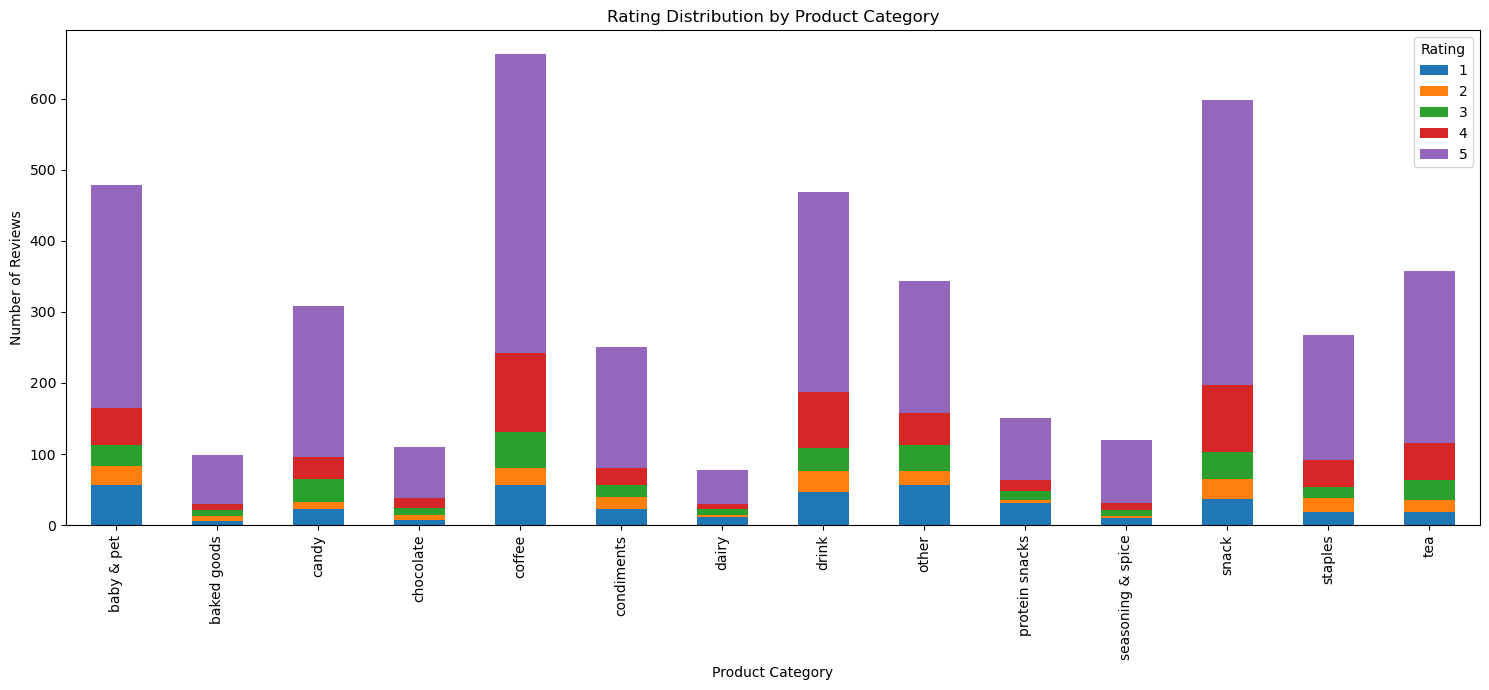

In [255]:
import matplotlib.pyplot as plt

cat_counts = DF.groupby(['analysis_category', 'Score']).size().unstack(fill_value=0)
cat_counts.plot(kind='bar', stacked=True, figsize=(15, 7))
plt.title("Rating Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Reviews")
plt.legend(title="Rating")
plt.tight_layout()
plt.show()

#### Step 3.5 Sentiment Analysis
In this Amazon Fine Food dataset, Product Score indicated users opinion towards the product, so the Sentiment Analysis is not necessary for this dataset. However, for other dataset like, reddit review, etc. A sentiment analysis is required. 

# Step 4: Keyword Extraction

In [259]:
# === Step 4 (improved): Unified, cleaner, more actionable keyphrases ===
import re, numpy as np, pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text

# -------- Params --------
DF_SRC      = ready_df   # needs: Cleaned_Text, Text, Score, analysis_category, Helpfulness*
CAT_COL     = 'analysis_category'
TEXT_COL    = 'Cleaned_Text'
RAW_COL     = 'Text'

POS_RANGE   = (4, 5)
NEG_RANGE   = (1, 3)

TOP_CATS    = 6
TOP_PHRASES = 15
MIN_DOCS    = 30

# Cohort-specific TF-IDF thresholds (negatives are sparser, so easier)
CFG_POS = dict(MIN_DF=3, MAX_DF=0.80, MAX_FEATS=500)
CFG_NEG = dict(MIN_DF=1, MAX_DF=0.90, MAX_FEATS=500)

NGRAMS      = (2,3)
WEIGHT_CAP  = 5
JACCARD_MAX = 0.5

# -------- Stopwords (domain-aware; KEEP negations) --------
domain_sw = {
    # platform/meta
    'amazon','seller','order','ordered','shipping','arrived',
    # generic fillers / non-actionable
    'product','thing','stuff','item','buy','bought','purchase','use','used','using','get','got','one',
    'really','just','also','even','much','many','lot','little','bit','make','made','makes','going',
    # vague praise/complaints you called unhelpful
    'delicious','yummy','good','great','nice','awesome','recommend','highly','recommended','best','amazing',
    'love','like','favorite','favorites','perfect','wonderful','terrible','awful','bad','ok','okay',
    # too generic food words
    'food','roast','drink','drinks'
}
BASE_SW = (set(text.ENGLISH_STOP_WORDS) | domain_sw) - {"no","not","never","nor"}

# Phrases we never want (hand-curated junky outputs seen earlier)
PHRASE_BLOCKLIST = {
    'wake morning','personal taste','new favorite','long time','anyone please',
    'favorite tea','tea drink','favorite coffee','taste fine','year old','month old'
}

# -------- Helpers --------
def _review_weight(row):
    hn = row.get('HelpfulnessNumerator', 0) or 0
    hd = row.get('HelpfulnessDenominator', 0) or 0
    return 1.0 if hd == 0 else min(WEIGHT_CAP, 1.0 + hn/max(1, hd))

def _cat_self_terms(cat:str):
    toks = re.findall(r"[a-z]+", str(cat).lower())
    return set(toks) | {t.rstrip('s') for t in toks} | {t+'s' for t in toks}

def _pre_neg_join(s:str):
    return re.sub(r"\b(not|no|never)\s+([a-z]+)", r"\1_\2", str(s).lower())

def _jaccard_diverse(terms, top_k=TOP_PHRASES, max_overlap=JACCARD_MAX):
    picked, picked_sets = [], []
    for term in terms:
        s = set(term.split())
        if all((len(s & ps)/len(s | ps) <= max_overlap) for ps in picked_sets):
            picked.append(term); picked_sets.append(s)
        if len(picked) >= top_k: break
    return picked

def _valid_phrase(p, stopwords):
    if p in PHRASE_BLOCKLIST: return False
    toks = p.split()
    if len(toks) < NGRAMS[0]: return False
    if toks[0] in stopwords or toks[-1] in stopwords: return False
    if re.search(r"\d", p) or re.search(r"(.)\1{3,}", p): return False
    return True

def _extract_for_category(df_cat: pd.DataFrame, cat_name: str, min_df:int, max_df:float, max_feats:int):
    if len(df_cat) < MIN_DOCS: return []
    stopwords = BASE_SW | _cat_self_terms(cat_name)
    texts = df_cat[TEXT_COL].astype(str).map(_pre_neg_join).tolist()
    weights = df_cat.apply(_review_weight, axis=1).to_numpy()

    vec = TfidfVectorizer(
        ngram_range=NGRAMS,
        stop_words=list(stopwords),
        min_df=min_df, max_df=max_df, max_features=max_feats,
        token_pattern=r"(?u)\b[a-z_][a-z_]+\b"   # allow not_fresh
    )
    X = vec.fit_transform(texts)
    if X.shape[1] == 0: return []
    Xw = X.multiply(weights.reshape(-1,1))
    scores = np.asarray(Xw.sum(axis=0)).ravel()
    terms = vec.get_feature_names_out()
    ranked = [t for _,t in sorted(zip(scores, terms), reverse=True)]
    ranked = [p for p in ranked if _valid_phrase(p, stopwords)]
    return _jaccard_diverse(ranked)

def _coverage(df_cat, phrases_set):
    # % of reviews in df_cat whose 2–3grams include ≥1 phrase
    if len(df_cat) == 0 or len(phrases_set) == 0: return 0.0
    def grams(text):
        t = _pre_neg_join(text)
        toks = re.findall(r"[a-z_]+", t)
        s = set()
        for n in range(NGRAMS[0], NGRAMS[1]+1):
            s.update(" ".join(toks[i:i+n]) for i in range(0, max(0, len(toks)-n+1)))
        return s
    hits = sum(1 for txt in df_cat[TEXT_COL] if len(grams(txt) & phrases_set) > 0)
    return hits / len(df_cat)

def run_keyphrases(df: pd.DataFrame, lo:int, hi:int, sentiment_label:str):
    cohort = df[(df['Score'] >= lo) & (df['Score'] <= hi)].copy()
    vol = cohort[CAT_COL].value_counts()
    cats = [c for c in vol.index if vol[c] >= MIN_DOCS][:TOP_CATS]

    # pick cfg by cohort
    cfg = CFG_POS if sentiment_label == 'positive' else CFG_NEG

    results = {}
    rows = []
    cov_rows = []
    for cat in cats:
        sub = cohort[cohort[CAT_COL] == cat]
        phrases = _extract_for_category(sub, cat, cfg['MIN_DF'], cfg['MAX_DF'], cfg['MAX_FEATS'])
        results[cat] = phrases
        # tidy rows
        for r, phr in enumerate(phrases, 1):
            rows.append((cat, sentiment_label, r, phr, int(vol[cat])))
        # coverage metric
        cov = _coverage(sub, set(phrases))
        cov_rows.append((sentiment_label, cat, vol[cat], round(cov,3)))
    tidy = pd.DataFrame(rows, columns=[CAT_COL, 'sentiment', 'rank', 'phrase', 'cat_docs'])
    cov_df = pd.DataFrame(cov_rows, columns=['sentiment', CAT_COL, 'cat_docs', 'coverage'])
    return results, tidy, cov_df

# ---------- RUN ----------
pos_results, pos_tidy, pos_cov = run_keyphrases(DF_SRC, POS_RANGE[0], POS_RANGE[1], 'positive')
neg_results, neg_tidy, neg_cov = run_keyphrases(DF_SRC, NEG_RANGE[0], NEG_RANGE[1], 'negative')
keyphrases_tidy = pd.concat([pos_tidy, neg_tidy], ignore_index=True)
coverage_table  = pd.concat([pos_cov,  neg_cov],  ignore_index=True)

# ---------- Print (your style) ----------
print("\n==== POSITIVE REVIEWS (Score 4, 5) ====")
for cat, phrases in pos_results.items():
    print(f"{cat}: {phrases}")

print("\n==== NEUTRAL & NEGATIVE REVIEWS (Score 3, 2, 1) ====")
for cat, phrases in neg_results.items():
    print(f"{cat}: {phrases}")

# ---------- Quick quality check ----------
print("\nCoverage by sentiment & category (≥1 matched phrase in review):")
print(coverage_table.sort_values(['sentiment', CAT_COL]).to_string(index=False))

# ---------- Save for viz ----------
keyphrases_tidy.to_csv("keyphrases_by_sentiment.csv", index=False)
coverage_table.to_csv("keyphrase_coverage.csv", index=False)



==== POSITIVE REVIEWS (Score 4, 5) ====
coffee: ['green mountain', 'rich flavor', 'subscribe save', 'breakfast blend', 'french vanilla', 'vanilla flavor', 'strong flavor', 'extra bold', 'pleasantly surprised', 'black tiger', 'chocolate flavor', 'bitter taste', 'french press', 'tried brands', 'smooth tasting']
snack: ['grocery store', 'gluten free', 'salt vinegar', 'low fat', 'potato chips', 'chocolate chips', 'tortilla chips', 'peanut butter', 'local grocery', 'kettle chips', 'sea salt', 'pop chips', 'blue diamond', 'timely manner', 'family loves']
baby & pet: ['dog loves', 'subscribe save', 'loves treats', 'dogs treats', 'dog dog', 'right away', 'dry dog', 'german shepherd', 'dog treats', 'small dogs', 'small size', 'cat loves', 'pill pockets', 'picky eater', 'cats eat']
drink: ['coconut water', 'subscribe save', 'cream soda', 'mixed water', 'grocery stores', 'grocery store', 'root beer', 'red bull', 'years ago', 'cold water', 'add water', 'olive oil', 'lemon juice', 'crystal light',

# Step 5: Theme Discovery

In [314]:
# === THEME DISCOVERY · STEP 1 (REVISED): Build sentence corpus from raw Text ===
# Goal: split on ORIGINAL `Text` (keeps punctuation), then light-clean each sentence.
# Output: SENT (one row per sentence) with sentiment & category tags.

import re, html, pandas as pd

# -------- Inputs --------
DF = ready_df  # must contain: Text, Score, analysis_category (others optional)

# -------- Config (tweak as needed) --------
SCOPE_CAT            = None        # e.g. "coffee" or None for all
SCOPE_SENT           = "all"       # "positive", "negative", or "all"
MIN_TOK              = 8           # min tokens per sentence (after cleaning)
MAX_TOK              = 100        # max tokens per sentence
MAX_SENT_PER_REVIEW  = 3        # e.g. 3 to cap, or None for unlimited
DEDUP_SENTENCES      = True        # drop duplicate sentences within a review

# filter out boilerplate / logistics; loosen later if coverage is too low
DROP_PATTERNS = [
    r"\b(order(ed)?|arrived|shipping|shipment|seller|refund|package|delivered|prime)\b",
    r"https?://\S+|www\.\S+",
    r"\b(email|phone|customer service)\b"
]

# -------- Helpers --------
def light_clean(s: str) -> str:
    """Embedding-friendly clean: lowercase, strip HTML/URLs, keep negations."""
    if not isinstance(s, str): return ""
    t = html.unescape(s)
    t = re.sub(r'(<br\s*/?>)+', ' ', t, flags=re.I)
    t = re.sub(r'<[^>]+>', ' ', t)              # remove HTML tags
    t = t.replace("’", "'").lower()
    t = re.sub(r"https?://\S+|www\.\S+", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t

# simple, robust sentence splitter (works on RAW Text; no uppercase lookahead)
_SENT_SPLIT_RE = re.compile(r'(?<=[\.\!\?])\s+|[\n\r]+')

def sent_split_raw(text: str) -> list[str]:
    """Split ORIGINAL Text (with punctuation) into sentences; merge tiny fragments."""
    if not isinstance(text, str) or not text.strip():
        return []
    parts = re.split(_SENT_SPLIT_RE, text.strip())
    out, buf = [], ""
    for p in parts:
        p = p.strip()
        if not p: 
            continue
        # merge very short tail fragments (e.g., "!" or "?:")
        if len(p.split()) < 3 and buf:
            buf = (buf + " " + p).strip()
        else:
            if buf: out.append(buf)
            buf = p
    if buf: out.append(buf)
    return out

def keep_sentence(s: str, min_tok=MIN_TOK, max_tok=MAX_TOK) -> bool:
    """Length + pattern filters on the cleaned sentence."""
    toks = re.findall(r"[a-zA-Z']+", s)
    if not (min_tok <= len(toks) <= max_tok): 
        return False
    for pat in DROP_PATTERNS:
        if re.search(pat, s):
            return False
    return True

def label_sentiment(score: int) -> str:
    return "positive" if score >= 4 else ("negative" if score <= 3 else "neutral")

# -------- Prep & scope --------
df = DF.copy()

# sentiment (derive if missing)
if 'sentiment' not in df.columns:
    df['sentiment'] = df['Score'].astype(int).map(label_sentiment)

# fallbacks if Text is missing
if 'Text' not in df.columns:
    if 'Cleaned_Text' in df.columns:
        df['Text'] = df['Cleaned_Text']
    else:
        raise ValueError("Step 1 requires a 'Text' column (raw review text).")

# scope by category / sentiment
mask = pd.Series(True, index=df.index)
if SCOPE_CAT and 'analysis_category' in df.columns:
    mask &= (df['analysis_category'].str.lower() == str(SCOPE_CAT).lower())
if SCOPE_SENT in ("positive","negative"):
    mask &= (df['sentiment'] == SCOPE_SENT)
scoped = df.loc[mask].copy()

# -------- Explode to sentences --------
rows = []
for ridx, row in scoped.iterrows():
    raw_sents = sent_split_raw(row['Text'])                # split on RAW Text
    clean_sents = [light_clean(s) for s in raw_sents]      # then clean per sentence
    kept = [s for s in clean_sents if keep_sentence(s)]    # apply keep rules

    if DEDUP_SENTENCES:
        # drop duplicates within the same review (preserve order)
        seen, deduped = set(), []
        for s in kept:
            if s not in seen:
                seen.add(s); deduped.append(s)
        kept = deduped

    if MAX_SENT_PER_REVIEW is not None and len(kept) > MAX_SENT_PER_REVIEW:
        kept = kept[:MAX_SENT_PER_REVIEW]

    for j, s in enumerate(kept):
        rows.append({
            'review_idx': ridx,
            'sentence_idx': j,
            'sentence': s,
            'analysis_category': row.get('analysis_category'),
            'sentiment': row.get('sentiment'),
            'Score': int(row.get('Score', 0)),
            'ProductId': row.get('ProductId'),
            'review_dt': row.get('review_dt'),
            'year_month': row.get('year_month'),
        })

SENT = pd.DataFrame(rows)

# -------- Quick diagnostics --------
total_reviews = len(scoped)
total_sents   = len(SENT)
avg_sents     = (SENT.groupby('review_idx').size().mean() if total_reviews else 0)

print("=== STEP 1: Sentence Corpus (revised) ===")
print(f"Scope -> category: {SCOPE_CAT or 'ALL'} | sentiment: {SCOPE_SENT}")
print(f"Reviews in scope: {total_reviews:,}")
print(f"Sentences kept:   {total_sents:,}")
print(f"Avg sentences/review (kept): {avg_sents:.2f}")

# sample rows
if not SENT.empty:
    print("\nSample sentences:")
    print(SENT[['analysis_category','sentiment','sentence']].head(8).to_string(index=False))
else:
    print("\nNo sentences kept — consider loosening MIN/MAX_TOK or DROP_PATTERNS.")


=== STEP 1: Sentence Corpus (revised) ===
Scope -> category: ALL | sentiment: all
Reviews in scope: 4,292
Sentences kept:   9,954
Avg sentences/review (kept): 2.39

Sample sentences:
analysis_category sentiment                                                                                                        sentence
          staples  negative i don't know how long these sat on the back of a shelf somewhere, but they were so old that they wouldn't cook.
          staples  negative                                                    for now, i have about fifty servings of beans to throw away.
            dairy  positive              even though we are international delight fans we were not completely dissapointed by this product.
            candy  negative                                           the spicy version of this ketchup isn't bad, but it is too expensive.
            candy  negative                                                              the regular version is sweet

In [316]:
# === STEP 2: Sentence Embeddings ===
import numpy as np

# Ensure you have SENT from Step 1
assert 'sentence' in SENT.columns, "Run Step 1 first to build SENT DataFrame"

sent_texts = SENT['sentence'].astype(str).tolist()
print(f"Embedding {len(sent_texts)} sentences...")

BATCH = 100  # number of sentences per API call
embeddings = []

for i in range(0, len(sent_texts), BATCH):
    batch = sent_texts[i:i+BATCH]
    resp = client.embeddings.create(
        model="text-embedding-3-small",  # or "text-embedding-3-large"
        input=batch
    )
    batch_embeds = [d.embedding for d in resp.data]
    embeddings.extend(batch_embeds)
    print(f"Processed batch {i//BATCH + 1} / {len(sent_texts)//BATCH + 1}")

# Convert to NumPy array for clustering
emb_array = np.array(embeddings, dtype=np.float32)
print(f"Embedding matrix shape: {emb_array.shape}")

# Store back to SENT for traceability
SENT['embedding'] = list(emb_array)


Embedding 9954 sentences...
Processed batch 1 / 100
Processed batch 2 / 100
Processed batch 3 / 100
Processed batch 4 / 100
Processed batch 5 / 100
Processed batch 6 / 100
Processed batch 7 / 100
Processed batch 8 / 100
Processed batch 9 / 100
Processed batch 10 / 100
Processed batch 11 / 100
Processed batch 12 / 100
Processed batch 13 / 100
Processed batch 14 / 100
Processed batch 15 / 100
Processed batch 16 / 100
Processed batch 17 / 100
Processed batch 18 / 100
Processed batch 19 / 100
Processed batch 20 / 100
Processed batch 21 / 100
Processed batch 22 / 100
Processed batch 23 / 100
Processed batch 24 / 100
Processed batch 25 / 100
Processed batch 26 / 100
Processed batch 27 / 100
Processed batch 28 / 100
Processed batch 29 / 100
Processed batch 30 / 100
Processed batch 31 / 100
Processed batch 32 / 100
Processed batch 33 / 100
Processed batch 34 / 100
Processed batch 35 / 100
Processed batch 36 / 100
Processed batch 37 / 100
Processed batch 38 / 100
Processed batch 39 / 100
Proces

In [324]:
# === THEME DISCOVERY · STEP 3 (Improved): PCA→Standardize→HDBSCAN + auto-merge similar clusters ===
import numpy as np, pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

# ---- Inputs ----
assert 'embedding' in SENT.columns, "Run Step 2 first (SENT['embedding'])."
assert 'sentiment' in SENT.columns, "Step 1 should have added SENT['sentiment']."
assert SENT['embedding'].iloc[0] is not None, "Embeddings must be arrays/vectors."

# ---- Try HDBSCAN; fallback to KMeans if not available ----
try:
    import hdbscan
    _CLUSTERER = 'hdbscan'
except Exception:
    from sklearn.cluster import MiniBatchKMeans
    _CLUSTERER = 'kmeans'

# ---- Config ----
PCA_DIM              = 50
CONF_PROB_MIN        = 0.25   # drop very uncertain assignments
MIN_TOKEN_LEN        = 6      # drop sentences shorter than this (in tokens)
SIM_MERGE_THRESHOLD  = 0.92   # merge clusters whose centroids are >= this cosine sim (in original embedding space)
TOP_EXEMPLARS        = 3
RANDOM_SEED          = 42

# ---- Helpers ----
def _to_matrix(vecs):
    return np.vstack(vecs).astype(np.float32)

def _adaptive_min_cluster_size(n):
    # bigger cohorts → allow larger clusters; tiny cohorts → allow smaller
    # heuristic: 3*sqrt(n), clamped to [25, 120]
    return int(np.clip(3*np.sqrt(max(n,1)), 25, 120))

def _fit_reduce(X):
    pca = PCA(n_components=min(PCA_DIM, X.shape[1]-1), random_state=RANDOM_SEED)
    Xr = pca.fit_transform(X)
    # Standardize reduced space → better density estimation
    scaler = StandardScaler()
    Xz = scaler.fit_transform(Xr)
    return Xz, pca, scaler

def _cluster(Xz, min_cluster_size):
    if _CLUSTERER == 'hdbscan':
        min_samples = max(5, min_cluster_size // 2)  # a bit stricter than default
        clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size,
                                    min_samples=min_samples,
                                    metric='euclidean',
                                    prediction_data=True)
        labels = clusterer.fit_predict(Xz)
        probs  = getattr(clusterer, 'probabilities_', np.ones_like(labels, dtype=float))
        return labels, probs, clusterer
    else:
        from sklearn.cluster import MiniBatchKMeans
        k = max(3, int(np.sqrt(Xz.shape[0] / 5)))
        km = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_SEED, batch_size=1024, n_init='auto')
        labels = km.fit_predict(Xz)
        probs  = np.ones_like(labels, dtype=float)
        return labels, probs, km

def _exemplars(Xz, labels, probs, df_sent, topk=TOP_EXEMPLARS):
    """Pick exemplars per cluster prioritizing high confidence, then centroid proximity."""
    exemplars = {}
    uniq = [c for c in sorted(np.unique(labels)) if c != -1]
    for cl in uniq:
        idx = np.where(labels == cl)[0]
        if len(idx) == 0: 
            continue
        Xc = Xz[idx]
        pr = probs[idx]
        ctr = Xc.mean(axis=0, keepdims=True)
        d = np.linalg.norm(Xc - ctr, axis=1)
        # rank: higher prob first, then closer to centroid
        rank = np.lexsort((d, -pr))
        pick = idx[rank[:topk]]
        exemplars[int(cl)] = df_sent.iloc[pick][['analysis_category','sentiment','sentence']].to_dict('records')
    return exemplars

def _centroids_in_orig_space(labels, X_orig):
    """Compute centroids in ORIGINAL embedding space (for robust similarity)."""
    cents, cl_ids = [], []
    for cl in sorted(set(labels)):
        if cl == -1: 
            continue
        ix = np.where(labels == cl)[0]
        if ix.size == 0: 
            continue
        cents.append(X_orig[ix].mean(axis=0))
        cl_ids.append(int(cl))
    return np.vstack(cents), cl_ids

def _merge_similar_clusters(labels, X_orig, threshold=SIM_MERGE_THRESHOLD):
    """Merge clusters whose centroids are highly similar."""
    cents, cl_ids = _centroids_in_orig_space(labels, X_orig)
    if len(cl_ids) <= 1:
        return labels  # nothing to merge
    sim = cosine_similarity(cents)
    # simple greedy union-find style merge
    parent = {c:c for c in cl_ids}
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    def union(a,b):
        ra, rb = find(a), find(b)
        if ra != rb: parent[rb] = ra

    for i, ci in enumerate(cl_ids):
        for j, cj in enumerate(cl_ids):
            if j <= i: continue
            if sim[i,j] >= threshold:
                union(ci, cj)

    # relabel
    new_labels = labels.copy()
    for c in cl_ids:
        root = find(c)
        if root != c:
            new_labels[labels == c] = root
    return new_labels

def _prep_split(df_sent):
    # drop ultra-short sentences (token count)
    tok_len = df_sent['sentence'].astype(str).str.split().map(len)
    keep = tok_len >= MIN_TOKEN_LEN
    return df_sent.loc[keep].reset_index(drop=True)

def _run_one(df_sent: pd.DataFrame, title="cohort"):
    if df_sent.empty:
        return df_sent.assign(cluster_id=[], cluster_conf=[]), pd.Series(dtype=int), {}
    df_sent = _prep_split(df_sent)
    X_orig = _to_matrix(df_sent['embedding'].tolist())
    Xz, pca, scaler = _fit_reduce(X_orig)

    mcs = _adaptive_min_cluster_size(len(df_sent))
    labels, probs, model = _cluster(Xz, min_cluster_size=mcs)

    # confidence gate
    labels[(labels != -1) & (probs < CONF_PROB_MIN)] = -1

    # merge similar clusters (in original embed space)
    if _CLUSTERER == 'hdbscan':
        labels = _merge_similar_clusters(labels, X_orig, threshold=SIM_MERGE_THRESHOLD)

    out = df_sent.copy()
    out['cluster_id'] = labels
    out['cluster_conf'] = probs

    counts = out['cluster_id'].value_counts().sort_index()
    ex = _exemplars(Xz, labels, probs, df_sent)

    # info
    k_eff = (out['cluster_id'].nunique() - (1 if (-1 in out['cluster_id'].unique()) else 0))
    print(f"[{title}] n={len(df_sent)} | min_cluster_size={mcs} | clusters={k_eff} | noise={(out['cluster_id']==-1).mean():.1%}")
    return out, counts, ex

# ---- Split by sentiment ----
sent_pos = SENT[SENT['sentiment'] == 'positive'].reset_index(drop=True)
sent_neg = SENT[SENT['sentiment'] == 'negative'].reset_index(drop=True)

print(f"[Info] Positive sentences: {len(sent_pos):,}  |  Negative sentences: {len(sent_neg):,}")
if len(sent_pos) < 200: print("  (Heads up: POS is small; adaptive min_cluster_size will lower automatically.)")
if len(sent_neg) < 200: print("  (Heads up: NEG is small; adaptive min_cluster_size will lower automatically.)")

# ---- Run POS/NEG ----
pos_out, pos_counts, pos_ex = _run_one(sent_pos, title="POSITIVE")
neg_out, neg_counts, neg_ex = _run_one(sent_neg, title="NEGATIVE")
# Add sentence length for ranking exemplars
for df_ in [pos_out, neg_out]:
    df_['len'] = df_['sentence'].str.len()


# ---- Side-by-side summary ----
def _print_summary(title, counts, exemplars):
    print(f"\n=== {title} — clusters (including -1 noise) ===")
    if counts.empty:
        print("No sentences.")
        return
    print(counts.to_string())
    for cl, rows in exemplars.items():
        print(f"\n-- Cluster {cl} (examples) --")
        for r in rows:
            cat = r.get('analysis_category','?')
            snt = r.get('sentiment','?')
            txt = r.get('sentence','')[:280].strip()
            print(f"[{cat} | {snt}] {txt}")

_print_summary("POSITIVE", pos_counts, pos_ex)
_print_summary("NEGATIVE", neg_counts, neg_ex)

# ---- Save for next steps (labeling, trends) ----
pos_out.to_csv("themes_sentences_positive.csv", index=False)
neg_out.to_csv("themes_sentences_negative.csv", index=False)
print("\nSaved: themes_sentences_positive.csv, themes_sentences_negative.csv")
print(f"Clustering backend: {_CLUSTERER.upper()}")


[Info] Positive sentences: 7,714  |  Negative sentences: 2,240
[POSITIVE] n=7714 | min_cluster_size=120 | clusters=39 | noise=0.0%
[NEGATIVE] n=2240 | min_cluster_size=120 | clusters=21 | noise=0.0%

=== POSITIVE — clusters (including -1 noise) ===
cluster_id
0     169
1     247
2     217
3     211
4     243
5     180
6     203
7     253
8     149
9     127
10    203
11    155
12    165
13     55
14    177
15    207
16    192
17    219
18    221
19    193
20    174
21    141
22    185
23    411
24    167
25    204
26    135
27    351
28    304
29    296
30    176
31    108
32    173
33    154
34    205
35    196
36    210
37    167
38    171

-- Cluster 0 (examples) --
[other | positive] it works great in conjunction with the clear shampoo, but overall, i would use the conditioner and leave it on for a long time.
[tea | positive] it's very concentrated; a little bit will do a nice lather and it does what it promises, it cleans hair and scalp leaving a cool refreshing feeling with easy 

In [326]:
# Assuming:
# DF_SRC = your full reviews DataFrame (with Cleaned_Text, Score, analysis_category, etc.)
# SENT   = sentence-level DF from Step 1 (has 'sentence', 'analysis_category', 'sentiment')
# And 'orig_idx' was preserved when creating SENT (row index from DF_SRC).
# If you didn't store 'orig_idx', we can reconstruct it now if you still have the mapping.

# If 'orig_idx' is NOT in SENT, try to map using a join
if 'orig_idx' not in SENT.columns:
    SENT = SENT.reset_index().rename(columns={'index': 'orig_idx'})

# Count unique original reviews considered before Step 4
total_reviews_considered = SENT['orig_idx'].nunique()
print(f"Total reviews considered for theme extraction: {total_reviews_considered:,}")

# If you want to break it down by sentiment:
pos_reviews_count = SENT.loc[SENT['sentiment'] == 'positive', 'orig_idx'].nunique()
neg_reviews_count = SENT.loc[SENT['sentiment'] == 'negative', 'orig_idx'].nunique()

print(f"Positive reviews considered: {pos_reviews_count:,}")
print(f"Negative reviews considered: {neg_reviews_count:,}")


Total reviews considered for theme extraction: 9,954
Positive reviews considered: 7,714
Negative reviews considered: 2,240


In [402]:
# === THEME DISCOVERY · STEP 4 (Revised) ===
# Robust cluster → theme labeling + coverage (no row explosion, no MultiIndex issues)
import os, re, json, math
import numpy as np
import pandas as pd

# ---------------- Config ----------------
HIGH_THEMES = [
    "Flavor & Quality",
    "Price & Value",
    "Brewing/Use Convenience",   # prep, ease of use, cleanup, pack size, brew strength, etc.
    "Packaging/Delivery",
    "Health/Nutrition",
    "Customer Service",
    "Availability/Stock",
    "Other"
]
EXEMPLARS_PER_CLUSTER = 3        # sentences to show the LLM per cluster
CLUSTERS_PER_CALL     = 24       # map this many clusters per API call
SECOND_PASS_ON_OTHER  = False    # set True to re-run only clusters that came back "Other"
RANDOM_SEED           = 42

# ---------------- Sanity helpers ----------------
REQ_COLS = ["analysis_category","sentiment","sentence","cluster_id","cluster_conf"]

def _normalize_cluster_id(df: pd.DataFrame) -> pd.DataFrame:
    """Ensure a real 'cluster_id' column (int), not stuck in the index; avoid duplicate insert."""
    out = df.copy()
    # If 'cluster_id' is already a column, keep it
    if 'cluster_id' in out.columns:
        pass
    # Else, if the index is named 'cluster_id' (or includes it), move it to a column
    elif out.index.name == 'cluster_id' or ('cluster_id' in (out.index.names or [])):
        out = out.reset_index()
    else:
        # Nothing we can do automatically
        raise ValueError("Missing 'cluster_id' column. Make sure Step 3 saved it into the dataframe.")
    # Clean dtype
    out['cluster_id'] = pd.to_numeric(out['cluster_id'], errors='coerce').fillna(-1).astype(int)
    return out

def _ensure_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Make sure required columns exist & are well-typed."""
    out = _normalize_cluster_id(df)
    if 'cluster_conf' not in out.columns:
        out['cluster_conf'] = 1.0
    out['cluster_conf'] = pd.to_numeric(out['cluster_conf'], errors='coerce').fillna(1.0).clip(0, 1)
    if 'sentiment' not in out.columns and 'Score' in out.columns:
        out['sentiment'] = out['Score'].apply(lambda x: 'positive' if x >= 4 else 'negative')
    # Sentence length fields for exemplar picking (avoid KeyError: 'len')
    out['char_len'] = out['sentence'].astype(str).str.len()
    out['tok_len']  = out['sentence'].astype(str).str.split().map(len)
    # Keep only the columns we actually use downstream + anything useful you already had
    keep = list(dict.fromkeys(REQ_COLS + ['char_len','tok_len','ProductId','review_dt','year_month','Score']))
    keep = [c for c in keep if c in out.columns]
    return out[keep + [c for c in out.columns if c not in keep]]

def _pick_exemplars(df_cluster: pd.DataFrame, k: int = EXEMPLARS_PER_CLUSTER):
    """Pick the most representative sentences for 1 cluster: prioritize conf, then length ~ median."""
    if df_cluster.empty:
        return []
    g = df_cluster.copy()
    med = g['char_len'].median() if not math.isnan(g['char_len'].median()) else 80
    # Rank: higher conf first, then closeness to median length, then more tokens
    order = np.lexsort((
        -g['tok_len'].to_numpy(),
         (g['char_len'] - med).abs().to_numpy(),
        -g['cluster_conf'].to_numpy()
    ))
    sents = g.iloc[order][:k]['sentence'].astype(str).tolist()
    # Clip each exemplar to ~240 chars for prompt neatness
    return [re.sub(r'\s+', ' ', s).strip()[:240] for s in sents]

def _chunks(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]

def _load_CLUST_or_die() -> pd.DataFrame:
    """Get the unified clustered sentences dataframe."""
    if 'CLUST' in globals():
        df = globals()['CLUST']
        return _ensure_columns(df)
    # fallback: try load the CSVs saved in Step 3
    pos_csv = "themes_sentences_positive.csv"
    neg_csv = "themes_sentences_negative.csv"
    if os.path.exists(pos_csv) and os.path.exists(neg_csv):
        df = pd.concat([pd.read_csv(pos_csv), pd.read_csv(neg_csv)], ignore_index=True)
        df = df.rename(columns=str)  # ensure str cols
        # Make sure required cols exist even if csvs were older format
        if 'sentence' not in df.columns:
            # old dumps sometimes used 'Text' column name
            cand = [c for c in df.columns if c.lower() in ('sentence','theme_text','text')]
            if cand: df['sentence'] = df[cand[0]]
        return _ensure_columns(df)
    raise ValueError("No CLUST in memory and theme csvs not found. Run Step 3 first to produce clustered sentences.")

# ---------------- LLM mapping (single call path) ----------------
def _build_prompt_block(cid: int, examples: list[str]) -> str:
    lines = [f"- cluster_id={cid}"]
    for i, s in enumerate(examples, 1):
        lines.append(f"  example{i}: {s}")
    return "\n".join(lines)

def _build_mapping_prompt(blocks: list[str]) -> str:
    return (
        "You are labeling themes for e‑commerce food/beverage reviews.\n"
        "For each cluster, map to ONE high-level theme from this fixed list:\n"
        f"{', '.join(HIGH_THEMES)}\n"
        "Also provide a short specific lower_theme (e.g., 'too bitter', 'stale', 'leaks', 'overpriced', "
        "'easy to brew', 'k-cup compatibility', 'digestive issues', 'arrived damaged').\n\n"
        "Rules:\n"
        "• Always choose EXACTLY one high_theme from the list.\n"
        "• If none fits, use 'Other'.\n"
        "• Keep lower_theme short (2–4 words), concrete, and informative.\n"
        "• Base only on the examples shown; do not invent.\n\n"
        "Clusters:\n"
        f"{chr(10).join(blocks)}\n\n"
        "Return one JSON object per line with keys: cluster_id, high_theme, lower_theme.\n"
        "Example output line: {\"cluster_id\": 12, \"high_theme\": \"Flavor & Quality\", \"lower_theme\": \"too bitter\"}"
    )

def _parse_jsonl(text: str) -> list[dict]:
    out = []
    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue
        try:
            obj = json.loads(line)
            if isinstance(obj, dict) and 'cluster_id' in obj:
                out.append(obj)
        except Exception:
            # very forgiving fallback: try to salvage with regex
            m_id = re.search(r'cluster_id[^0-9-]*(-?\d+)', line)
            m_hi = re.search(r'high_theme[^"]*"([^"]+)"', line)
            m_lo = re.search(r'lower_theme[^"]*"([^"]+)"', line)
            if m_id:
                out.append({
                    "cluster_id": int(m_id.group(1)),
                    "high_theme": m_hi.group(1) if m_hi else "Other",
                    "lower_theme": m_lo.group(1) if m_lo else "other"
                })
    return out

def _llm_map_clusters(df: pd.DataFrame, client) -> tuple[dict, dict]:
    """Return (cluster_id -> high_theme, cluster_id -> lower_theme)."""
    if client is None:
        raise ValueError("client is None. Pass your existing OpenAI client to step4_label_and_consolidate(client).")
    # Prepare exemplars per cluster
    clusters = []
    for cid, g in df.groupby('cluster_id', sort=True):
        if cid == -1 or g.empty:
            continue
        ex = _pick_exemplars(g, EXEMPLARS_PER_CLUSTER)
        clusters.append((int(cid), ex))
    # Batch calls
    hi_map, lo_map = {}, {}
    for group in _chunks(clusters, CLUSTERS_PER_CALL):
        blocks = [_build_prompt_block(cid, ex) for cid, ex in group]
        prompt = _build_mapping_prompt(blocks)
        resp = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=[{"role":"user","content": prompt}],
            max_tokens=800,
            temperature=0
        )
        parsed = _parse_jsonl(resp.choices[0].message.content)
        # Merge
        for obj in parsed:
            cid = int(obj.get('cluster_id', -1))
            hi = str(obj.get('high_theme', 'Other')).strip()
            lo = str(obj.get('lower_theme', 'other')).strip()
            # Clamp to fixed list
            hi = hi if hi in HIGH_THEMES else "Other"
            hi_map[cid] = hi
            lo_map[cid] = lo
        # Any missing from this batch -> Other
        in_batch = {cid for cid, _ in group}
        for cid in in_batch - set(hi_map.keys()):
            hi_map[cid] = "Other"
            lo_map[cid] = "other"
    return hi_map, lo_map

def _second_pass_on_other(df: pd.DataFrame, hi_map: dict, client) -> dict:
    """Optional: tighten 'Other' by asking LLM to re-label those clusters with strict choices."""
    if client is None:
        return {}
    cids_other = [c for c, th in hi_map.items() if th == "Other"]
    updates = {}
    if not cids_other:
        return updates
    for chunk in _chunks(cids_other, CLUSTERS_PER_CALL):
        blocks = []
        for cid in chunk:
            ex = _pick_exemplars(df[df['cluster_id'] == cid], EXEMPLARS_PER_CLUSTER)
            blocks.append(_build_prompt_block(cid, ex))
        prompt = (
            "Reconsider ONLY these clusters currently labeled 'Other'. "
            f"Choose one of: {', '.join(HIGH_THEMES[:-1])} (do NOT use 'Other' unless impossible).\n\n"
            "Clusters:\n" + "\n".join(blocks) + "\n\n"
            "Return JSON lines: {\"cluster_id\": <int>, \"high_theme\": \"...\"}"
        )
        resp = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=[{"role":"user","content": prompt}],
            max_tokens=600,
            temperature=0
        )
        parsed = _parse_jsonl(resp.choices[0].message.content)
        for obj in parsed:
            cid = int(obj.get('cluster_id', -1))
            hi  = str(obj.get('high_theme', 'Other')).strip()
            if hi and hi in HIGH_THEMES and hi != "Other":
                updates[cid] = hi
    return updates

# ---------------- Main entry ----------------
def step4_label_and_consolidate(client):
    # 0) Load clustered sentences
    df = _load_CLUST_or_die()
    df = _ensure_columns(df)

    # 1) Primary mapping (cluster -> themes)
    hi_map, lo_map = _llm_map_clusters(df, client=client)

    # 2) Optional second pass to reduce Other
    if SECOND_PASS_ON_OTHER:
        updates = _second_pass_on_other(df, hi_map, client=client)
        for cid, new_hi in updates.items():
            hi_map[cid] = new_hi

    # 3) Apply mapping (no row explosion)
    df['high_theme']  = df['cluster_id'].map(hi_map).fillna("Other")
    df['lower_theme'] = df['cluster_id'].map(lo_map).fillna("other")

    # 4) theme_size: sentences per (sentiment, analysis_category, high_theme)
    theme_counts = (df
        .groupby(['sentiment','analysis_category','high_theme'])
        .size()
        .reset_index(name='theme_size'))
    df = df.merge(theme_counts,
                  on=['sentiment','analysis_category','high_theme'],
                  how='left')

    # 5) Coverage (tidy; no MultiIndex)
    cov = (df
           .groupby(['sentiment','analysis_category','high_theme'])
           .size()
           .reset_index(name='sentences'))
    tot = cov.groupby(['sentiment','analysis_category'])['sentences'] \
             .sum().reset_index(name='total_sents')
    cov = cov.merge(tot, on=['sentiment','analysis_category'], how='left')
    cov['share_pct'] = (100 * cov['sentences'] / cov['total_sents']).round(1)

    # 6) Quick sanity (no drops)
    print("\n=== Sanity ===")
    print("Rows in CLUST:", len(df))
    recon = cov.groupby(['sentiment','analysis_category'])['sentences'].sum().sum()
    print("Rows represented in coverage:", int(recon))

    # 7) Save + return
    df_out = df[['analysis_category','sentiment','cluster_id','cluster_conf',
                 'sentence','high_theme','lower_theme','theme_size',
                 'ProductId','review_dt','year_month','Score']].copy()
    df_out.to_csv("themes_sentences_labeled.csv", index=False)
    cov.to_csv("themes_coverage_summary.csv", index=False)
    print("Saved: themes_sentences_labeled.csv, themes_coverage_summary.csv")

    # 8) Small peek
    print("\n=== High-level coverage (top 20) ===")
    print(cov.sort_values(['sentiment','analysis_category','sentences'],
                          ascending=[True,True,False]).head(20).to_string(index=False))
    for th in ["Flavor & Quality","Price & Value","Brewing/Use Convenience",
               "Packaging/Delivery","Health/Nutrition","Other"]:
        ex = df_out[df_out['high_theme'] == th].head(2)[['analysis_category','sentiment','sentence']]
        if not ex.empty:
            print(f"\n[{th}]")
            for _, r in ex.iterrows():
                print(f"- ({r['analysis_category']} | {r['sentiment']}) {r['sentence'][:240]}")

    return df_out, cov, hi_map, lo_map

# ---------- RUN ----------
LBL, COVERAGE, HI_MAP, LO_MAP = step4_label_and_consolidate(client)



=== Sanity ===
Rows in CLUST: 9954
Rows represented in coverage: 9954
Saved: themes_sentences_labeled.csv, themes_coverage_summary.csv

=== High-level coverage (top 20) ===
sentiment analysis_category         high_theme  sentences  total_sents  share_pct
 negative        baby & pet   Health/Nutrition        157          278       56.5
 negative        baby & pet              Other         53          278       19.1
 negative        baby & pet   Flavor & Quality         48          278       17.3
 negative        baby & pet Packaging/Delivery         16          278        5.8
 negative        baby & pet      Price & Value          4          278        1.4
 negative       baked goods Packaging/Delivery         19           53       35.8
 negative       baked goods   Flavor & Quality         17           53       32.1
 negative       baked goods      Price & Value          9           53       17.0
 negative       baked goods              Other          8           53       15.1
 negat

In [406]:
# Totals by sentiment (should sum to 9,954)
print(COVERAGE.groupby('sentiment')['sentences'].sum())

# Totals by (sentiment, category)
print(COVERAGE.groupby(['sentiment','analysis_category'])['sentences'].sum().sort_values(ascending=False))

# Drill into one category (e.g., coffee, negative) to see all themes
cat, snt = 'coffee', 'positive'
print(
    COVERAGE[(COVERAGE['analysis_category']==cat) & (COVERAGE['sentiment']==snt)]
      .sort_values('sentences', ascending=False)
      .to_string(index=False)
)

sentiment
negative    2240
positive    7714
Name: sentences, dtype: int64
sentiment  analysis_category
positive   coffee               1244
           snack                1127
           drink                 876
           baby & pet            870
           tea                   690
           candy                 549
           staples               492
           other                 452
           condiments            451
negative   coffee                323
           baby & pet            278
           drink                 271
positive   protein snacks        241
negative   snack                 238
positive   seasoning & spice     223
negative   other                 219
positive   chocolate             202
           baked goods           172
negative   tea                   161
           candy                 160
           condiments            137
positive   dairy                 125
negative   staples               120
           protein snacks        112
         